In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import yaml

from pmt_analysis import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Read Data

In [2]:
data_dir = Path("data/calibLED/260611/segmented_wTrig")
# files = sorted(data_dir.glob("southCovered_525MHz_fewHours_trig1800uV-1.h5")) 
files = sorted(data_dir.glob("southCovered_525MHz_fewHours_trig1800uV-*.h5")) 

for file in files:
    print(file)
print(f"Number of files: {len(files)}")

data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-1.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-10.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-2.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-3.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-4.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-5.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-6.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-7.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-8.h5
data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-9.h5
Number of files: 10


In [3]:
maxEvts = 1000 # small sample size
time_s, voltage_sample_V, metadata = read_keysight_h5_direct(
    files[0],
    segment_numbers=range(maxEvts),
)
time_ns, voltage_sample_mV, adc_step_mV, units_time, units_voltage = standard_units(
    time_s,
    voltage_sample_V,
    metadata,
)

print(f"Sample waveforms: {voltage_sample_mV.shape}")
print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
print(f"ADC step: {adc_step_mV:.6f} mV")

Sample waveforms: (999, 1000)
Time range: -27.275 to 35.163 ns
Sampling step: 0.06250 ns
ADC step: 0.001276 mV


# Set Config. Values

In [4]:
# default config
with open('config_default.yml', 'r') as file:
    # Load and parse the YAML content safely
    config = yaml.safe_load(file)['DC_525MHz_fewHours_trig1800uV']['general']

## config
baseline_window_ns = (time_ns[0], time_ns[0]+config['baseline_window_width_ns'])
integration_window_ns  = (config['integration_window_ns'][0], config['integration_window_ns'][1])
peak_search_window_ns  = (config['peak_search_window_ns'][0], config['peak_search_window_ns'][1])
allowed_peak_window_ns = (config['allowed_peak_window_ns'][0], config['allowed_peak_window_ns'][1])
global_peak_voltage_max_mV = None if (config['global_peak_voltage_max_mV']=='None') else (config['global_peak_voltage_max_mV'])
out_of_window_peak_voltage_max_mV = config['out_of_window_peak_voltage_max_mV']

config



{'baseline_window_width_ns': 20,
 'integration_window_ns': [-1, 9],
 'peak_search_window_ns': [-1, 9],
 'global_peak_voltage_max_mV': 'None',
 'out_of_window_peak_voltage_max_mV': -1.8,
 'allowed_peak_window_ns': [-1, 9]}

In [5]:
### not in config
# threshold_for_mean_mV = 0. # threshold to compute mean waveform (if no cut, the baseline dominates)
threshold_for_mean_mV = out_of_window_peak_voltage_max_mV # threshold to compute mean waveform (if no cut, the baseline dominates)
rise_low_fraction = 0.1
rise_high_fraction = 0.9
show_residual_errorbars = True



# Baseline Subtraction

In [6]:
voltage_sample_bs_mV, sample_baseline_mV = subtract_baseline(
    time_ns,
    voltage_sample_mV,
    baseline_window_ns=baseline_window_ns,
)

In [7]:
summary = summarize_waveforms(
    files,
    baseline_window_ns=baseline_window_ns,
    chunk_size=4096,
    selection_mask=None
)

print(f'{summary.keys()} \n')

mean_waveform = summary["mean_waveform_mV"]
idx_min = int(np.argmin(mean_waveform))

print(f"Processed events: {summary['n_events']}")
print(f"Baseline window: {baseline_window_ns[0]:.1f}-{baseline_window_ns[1]:.1f} ns")
print(f"Baseline mean/std: {np.mean(summary['baseline_mV']):.4f} +/- {np.std(summary['baseline_mV']):.4f} mV")
print(f"Residual in baseline window: {np.mean(summary['baseline_check_mV']):.3e} +/- {np.std(summary['baseline_check_mV']):.3e} mV")
print(f"Mean waveform minimum: {summary['time_ns'][idx_min]:.3f} ns, {mean_waveform[idx_min]:.4f} mV")

dict_keys(['n_events', 'time_ns', 'mean_waveform_mV', 'std_waveform_mV', 'baseline_mV', 'baseline_check_mV', 'pulse_min_time_ns', 'pulse_amplitude_mV']) 

Processed events: 316820
Baseline window: -27.3--7.3 ns
Baseline mean/std: -0.1263 +/- 0.1883 mV
Residual in baseline window: 1.177e-09 +/- 1.070e-07 mV
Mean waveform minimum: 4.198 ns, -1.6047 mV


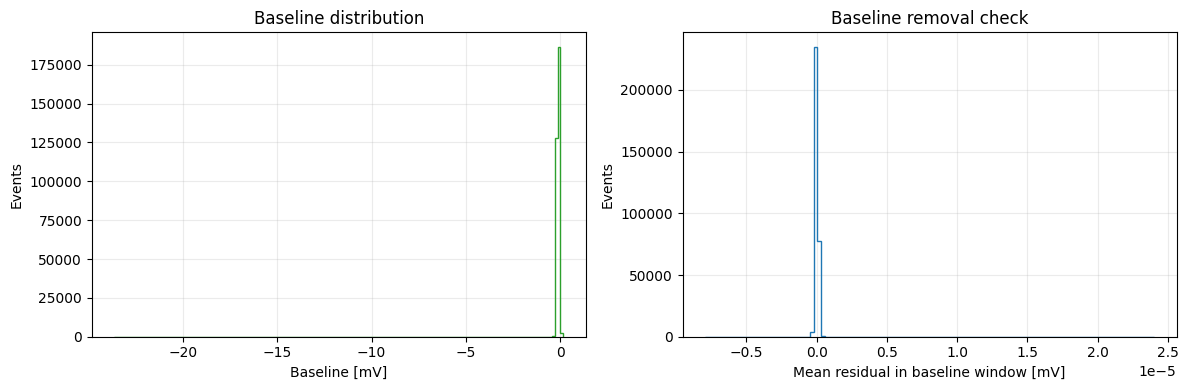

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(summary["baseline_mV"], bins=160, histtype="step", color="tab:green")
axes[0].set_xlabel("Baseline [mV]")
axes[0].set_ylabel("Events")
axes[0].set_title("Baseline distribution")
# axes[0].set_yscale('log')

axes[1].hist(summary["baseline_check_mV"], bins=120, histtype="step", color="tab:blue")
axes[1].set_xlabel("Mean residual in baseline window [mV]")
axes[1].set_ylabel("Events")
axes[1].set_title("Baseline removal check")
fig.tight_layout()

## Look at a small data sample

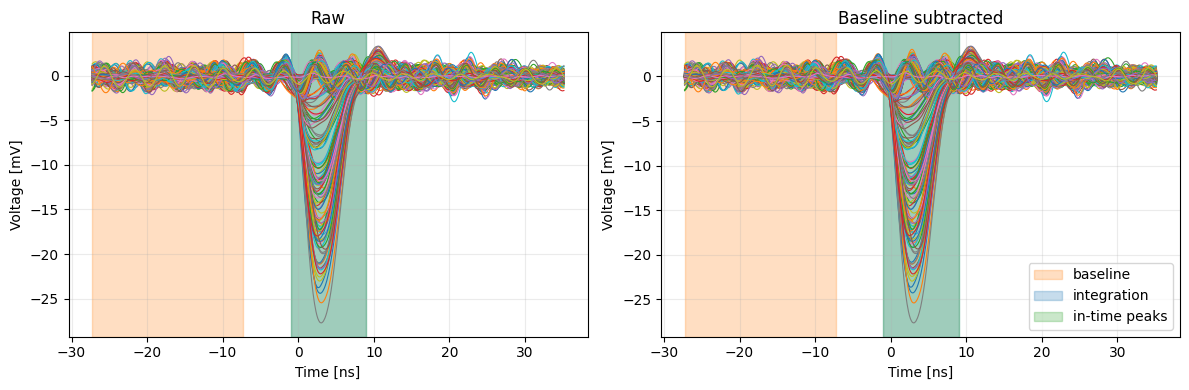

In [9]:
show_wfs = True

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for waveform in voltage_sample_mV[:maxEvts]:
    if show_wfs:
        axes[0].plot(time_ns, waveform, lw=0.8)
    else:
        axes[0].plot(time_ns, waveform, color="0.45", alpha=0.12, lw=0.8)
for waveform in voltage_sample_bs_mV[:maxEvts]:
    if show_wfs:
        axes[1].plot(time_ns, waveform, lw=0.8)
    else:
        axes[1].plot(time_ns, waveform, color="tab:blue", alpha=0.12, lw=0.8)

for ax in axes:
    ax.axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    ax.axvspan(*integration_window_ns, color="tab:blue", alpha=0.25, label="integration")
    ax.axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.25, label="in-time peaks")
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("Voltage [mV]")
axes[0].set_title("Raw")
axes[1].set_title("Baseline subtracted")
axes[1].legend(loc="lower right")
fig.tight_layout()

# Selection

- remove peaks that are clearely out of time (+ small threshold to define "a peak")

In [10]:
selection = collect_peak_time_voltage_selection(
    files,
    baseline_window_ns=baseline_window_ns,
    peak_window_ns=allowed_peak_window_ns,
    global_peak_voltage_max_mV=global_peak_voltage_max_mV, # cut all events with peak higher below a cut (i.e. remove small waveforms)
    out_of_window_peak_voltage_max_mV= out_of_window_peak_voltage_max_mV,
    peak_search_window_ns=peak_search_window_ns,
    selection_mask=None,
    chunk_size=4096,
    low_fraction=rise_low_fraction,
    high_fraction=rise_high_fraction,
)
print(f'selection efficiency = {selection['efficiency']*100} %  ({selection['n_kept']} / {selection['n_total']})')
print(f'events whose peak passes the “real pulse” voltage threshold (full time window) = {np.sum( selection['real_peak_mask'] )}')
print(f'events whose measured peak time is inside peak_window_ns    = {np.sum( selection['in_peak_window_mask'] )}')
mask = (selection['real_peak_mask']==True) & (selection['in_peak_window_mask']==True)
print(f'number of events with a "real peak" inside the selected peak widnow = {selection['peak_value_mV'][mask].shape[0]}')

for k in selection.keys():
    print(k)


selection efficiency = 100.0 %  (316820 / 316820)
events whose peak passes the “real pulse” voltage threshold (full time window) = 67961
events whose measured peak time is inside peak_window_ns    = 316820
number of events with a "real peak" inside the selected peak widnow = 67961
keep_mask
n_total
n_kept
efficiency
real_peak_mask
in_peak_window_mask
peak_time_ns
peak_value_mV
peak_amplitude_mV
t_low_ns
t_high_ns
rise_time_ns
rise_time_valid
low_fraction
high_fraction


In [24]:
print(f'selection efficiency = {selection['efficiency']*100} %  ({selection['n_kept']} / {selection['n_total']})')
print(f'events whose peak passes the “real pulse” voltage threshold (full time window) = {np.sum( selection['real_peak_mask'] )}')
print(f'events whose measured peak time is inside peak_window_ns    = {np.sum( selection['in_peak_window_mask'] )}')
mask = (selection['real_peak_mask']==True) & (selection['in_peak_window_mask']==True)
real_peaks_sel = selection['peak_value_mV'][mask]
print(f'number of events with a "real peak" inside the selected peak widnow = {real_peaks_sel.shape[0]}  ({real_peaks_sel.shape[0]*100 / selection['n_total']:.2f} %)')

selection efficiency = 100.0 %  (316820 / 316820)
events whose peak passes the “real pulse” voltage threshold (full time window) = 67961
events whose measured peak time is inside peak_window_ns    = 316820
number of events with a "real peak" inside the selected peak widnow = 67961  (21.45 %)


## Display some stats. (small sample)

In [12]:
sample_n = len(voltage_sample_bs_mV)
sample_timing = {
    key: selection[key][:sample_n]
    for key in [
        "peak_time_ns",
        "peak_value_mV",
        "peak_amplitude_mV",
        "t_low_ns",
        "t_high_ns",
        "rise_time_ns",
        "rise_time_valid",
        "real_peak_mask",
        "in_peak_window_mask",
        "keep_mask",
    ]
}

sample_selection_mask = sample_timing["keep_mask"]
sample_real_peak_mask = sample_timing["real_peak_mask"] # Return events whose peak voltage passes a real-pulse threshold.
selected_sample_wfs = voltage_sample_bs_mV[sample_selection_mask]
selected_sample_mask = sample_selection_mask
selected_sample_peaks = {
    key: value[sample_selection_mask]
    for key, value in sample_timing.items()
    if isinstance(value, np.ndarray) and len(value) == sample_n
}

valid_rise_mask = sample_timing["rise_time_valid"] & sample_real_peak_mask

print(f"Peak search window: {peak_search_window_ns[0]:.1f}-{peak_search_window_ns[1]:.1f} ns")
print(f"Allowed peak window: {allowed_peak_window_ns[0]:.1f}-{allowed_peak_window_ns[1]:.1f} ns")
print(f"Global threshold: {global_peak_voltage_max_mV}")
print(f"Out-of-window real-pulse veto: reject peak voltage <= {out_of_window_peak_voltage_max_mV:.1f} mV only outside the allowed window")
print(f"Sample events with real peaks: {np.sum(sample_real_peak_mask)} / {len(sample_real_peak_mask)}") # computed in the full time range
print(f"Sample events kept by selection: {np.sum(sample_selection_mask)} / {len(sample_selection_mask)}")
print("Peak-time quantiles for real-peak sample events [ns]:", np.quantile(sample_timing["peak_time_ns"][sample_real_peak_mask], [0.05, 0.5, 0.95]))
print("10-90 rise-time quantiles for real-peak sample events [ns]:", np.quantile(sample_timing["rise_time_ns"][valid_rise_mask], [0.05, 0.5, 0.95]))

Peak search window: -1.0-9.0 ns
Allowed peak window: -1.0-9.0 ns
Global threshold: None
Out-of-window real-pulse veto: reject peak voltage <= -1.8 mV only outside the allowed window
Sample events with real peaks: 252 / 999
Sample events kept by selection: 999 / 999
Peak-time quantiles for real-peak sample events [ns]: [0.28788171 0.53788171 3.37225671]
10-90 rise-time quantiles for real-peak sample events [ns]: [ 1.93261939 16.47978949 27.29488042]


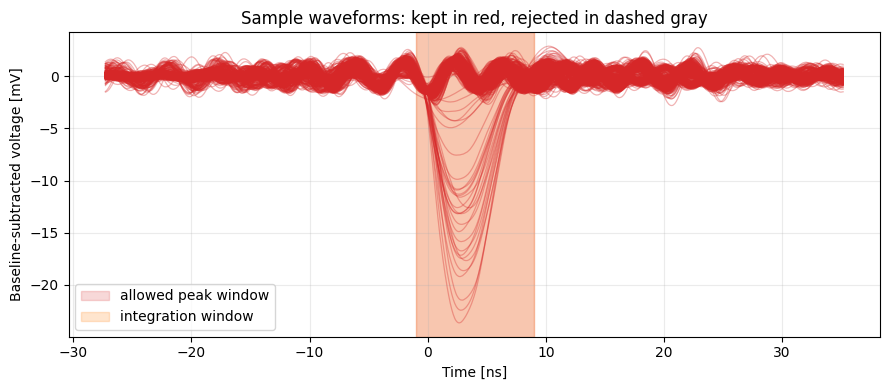

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
for waveform in voltage_sample_bs_mV[~sample_selection_mask][:500]:
    ax.plot(time_ns, waveform, color="tab:gray", lw=0.8, ls="--")
for waveform in selected_sample_wfs[:500]:
    ax.plot(time_ns, waveform, color="tab:red", alpha=0.35, lw=0.9)
ax.axvspan(*allowed_peak_window_ns, color="tab:red", alpha=0.18, label="allowed peak window")
ax.axvspan(*integration_window_ns, color="tab:orange", alpha=0.20, label="integration window")
ax.set_xlabel("Time [ns]")
ax.set_ylabel("Baseline-subtracted voltage [mV]")
ax.set_title("Sample waveforms: kept in red, rejected in dashed gray")
ax.legend()
fig.tight_layout()

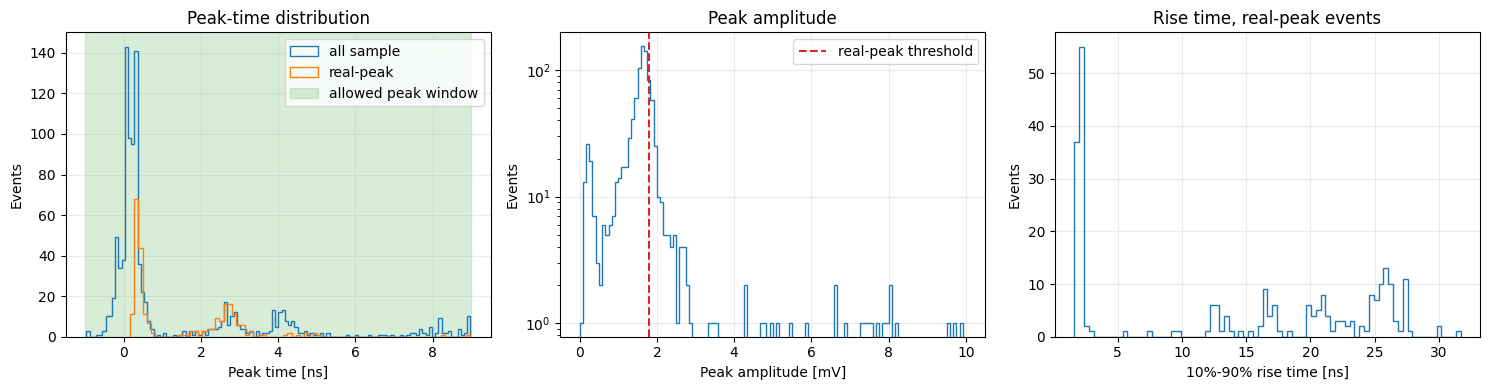

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(sample_timing["peak_time_ns"], bins=120, histtype="step", label="all sample")
axes[0].hist(sample_timing["peak_time_ns"][sample_real_peak_mask], bins=80, histtype="step", label="real-peak")
axes[0].axvspan(*allowed_peak_window_ns, color="tab:green", alpha=0.18, label="allowed peak window")
axes[0].set_xlabel("Peak time [ns]")
axes[0].set_ylabel("Events")
axes[0].set_title("Peak-time distribution")
axes[0].legend()

axes[1].hist(sample_timing["peak_amplitude_mV"], bins=120, range=(0, 10), histtype="step")
axes[1].axvline(abs(out_of_window_peak_voltage_max_mV), color="tab:red", ls="--", label="real-peak threshold")
axes[1].set_xlabel("Peak amplitude [mV]")
axes[1].set_ylabel("Events")
axes[1].set_title("Peak amplitude")
axes[1].set_yscale('log')
axes[1].legend()

axes[2].hist(sample_timing["rise_time_ns"][valid_rise_mask], bins=80, histtype="step")
axes[2].set_xlabel(f"{rise_low_fraction:.0%}-{rise_high_fraction:.0%} rise time [ns]")
axes[2].set_ylabel("Events")
axes[2].set_title("Rise time, real-peak events")
fig.tight_layout()

## Impact of the selection on the mean waveform

255
Amplitude cut: -1.8 mV -> 255/999 waveforms kept


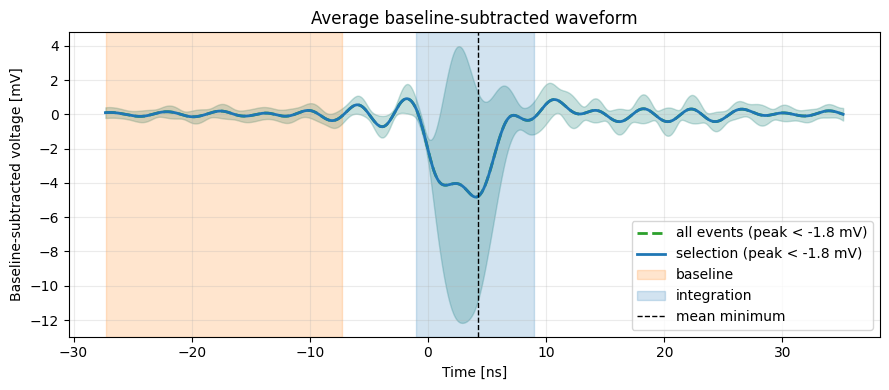

In [15]:
# ------------------------------------------------------------------
# Amplitude cut
# ------------------------------------------------------------------

# threshold_for_mean_mV = -2.  # set to None to disable
cut_text = (
    f" (peak < {threshold_for_mean_mV:.1f} mV)"
    if threshold_for_mean_mV is not None
    else ""
)

if threshold_for_mean_mV is not None:
    peak_amplitudes = np.min(voltage_sample_bs_mV, axis=1)
    threshold_mask = peak_amplitudes < threshold_for_mean_mV
    # print(threshold_mask)
    print( threshold_mask.sum() )

    print(
        f"Amplitude cut: {threshold_for_mean_mV:.1f} mV "
        f"-> {threshold_mask.sum()}/{len(threshold_mask)} waveforms kept"
    )

    voltage_sample_bs_mV_thr = voltage_sample_bs_mV[threshold_mask]
    selected_sample_wfs_thr = selected_sample_wfs[
        np.min(selected_sample_wfs, axis=1) < threshold_for_mean_mV
    ]
else:
    voltage_sample_bs_mV_thr = voltage_sample_bs_mV
    selected_sample_wfs_thr = selected_sample_wfs


# ------------------------------------------------------------------
# Means and RMS
# ------------------------------------------------------------------

mean_all = np.mean(voltage_sample_bs_mV_thr, axis=0)
std_all = np.std(voltage_sample_bs_mV_thr, axis=0)

mean_selected = np.mean(selected_sample_wfs_thr, axis=0)
std_selected = np.std(selected_sample_wfs_thr, axis=0)


# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 4))

# All events
ax.plot( summary["time_ns"], mean_all, color="tab:green", lw=2, ls="--", label=f"all events{cut_text}")
ax.fill_between( summary["time_ns"], mean_all - std_all, mean_all + std_all, color="tab:green", alpha=0.12)

# Fully selected events
ax.plot( summary["time_ns"], mean_selected, color="tab:blue", lw=2, label=f"selection{cut_text}")
ax.fill_between( summary["time_ns"], mean_selected - std_selected, mean_selected + std_selected, color="tab:blue", alpha=0.15)

ax.axvspan( *baseline_window_ns, color="tab:orange", alpha=0.20, label="baseline")
ax.axvspan( *integration_window_ns, color="tab:blue", alpha=0.20, label="integration")

ax.axvline( summary["time_ns"][idx_min], color="black", ls="--", lw=1, label="mean minimum" )

ax.set_xlabel("Time [ns]")
ax.set_ylabel("Baseline-subtracted voltage [mV]")
ax.set_title("Average baseline-subtracted waveform")
ax.legend(loc="best")
fig.tight_layout()

# Charge

## Best integration window selection

not really used for now

In [16]:
candidate_windows_ns = [
    integration_window_ns
]

charges_by_window = compute_charges_for_windows(
    files,
    baseline_window_ns=baseline_window_ns,
    integration_windows_ns=candidate_windows_ns,
    selection_mask=None,
    chunk_size=4096,
)

print("Original-data candidate fixed-window charges")
print("window [ns]      q0.1%      q1%       q50%      q90%      q99%    q99.9%   [mV ns]")
for window, charge_values in charges_by_window.items():
    q = np.quantile(charge_values, [0.001, 0.01, 0.5, 0.90, 0.99, 0.999])
    print(
        f"{window[0]:4.0f}-{window[1]:<4.0f}"
        f" {q[0]:10.3f} {q[1]:9.3f} {q[2]:9.3f} {q[3]:9.3f} {q[4]:9.3f} {q[5]:9.3f}"
    )

Original-data candidate fixed-window charges
window [ns]      q0.1%      q1%       q50%      q90%      q99%    q99.9%   [mV ns]
  -1-9        -1.822    -1.132     0.990     2.751    95.265   125.581


In [17]:
charge_all_mV_ns = charges_by_window[integration_window_ns]

print(f"Selected integration window: {integration_window_ns[0]:.1f}-{integration_window_ns[1]:.1f} ns")
print("Original-data charge quantiles [mV ns]:")
for prob, value in zip(
    [0.001, 0.01, 0.10, 0.50, 0.90, 0.99, 0.999],
    np.quantile(charge_all_mV_ns, [0.001, 0.01, 0.10, 0.50, 0.90, 0.99, 0.999]),
):
    print(f"  q{prob:0.3f}: {value:9.4f}")

Selected integration window: -1.0-9.0 ns
Original-data charge quantiles [mV ns]:
  q0.001:   -1.8221
  q0.010:   -1.1318
  q0.100:   -0.2684
  q0.500:    0.9900
  q0.900:    2.7509
  q0.990:   95.2646
  q0.999:  125.5812


## Compute Charge

In [18]:
selected_charges_by_window = compute_charges_for_windows(
    files,
    baseline_window_ns=baseline_window_ns,
    integration_windows_ns=[integration_window_ns],
    selection_mask=selection["keep_mask"],
    chunk_size=4096,
)
charge_selected_mV_ns = selected_charges_by_window[integration_window_ns]

print(f"Selected events: {selection['n_kept']} / {selection['n_total']} ({selection['efficiency']:.3%})")
print("Selected-data charge quantiles [mV ns]:")
if len(charge_selected_mV_ns):
    for prob, value in zip(
        [0.001, 0.01, 0.10, 0.50, 0.90, 0.99, 0.999],
        np.quantile(charge_selected_mV_ns, [0.001, 0.01, 0.10, 0.50, 0.90, 0.99, 0.999]),
    ):
        print(f"  q{prob:0.3f}: {value:9.4f}")
else:
    print("  no events kept")

Selected events: 316820 / 316820 (100.000%)
Selected-data charge quantiles [mV ns]:
  q0.001:   -1.8221
  q0.010:   -1.1318
  q0.100:   -0.2684
  q0.500:    0.9900
  q0.900:    2.7509
  q0.990:   95.2646
  q0.999:  125.5812


Approximate peak positions [ns]: [0.15671004 2.71826978 4.15524232]
Approximate spacings [ns]: [2.56155974 1.43697254]


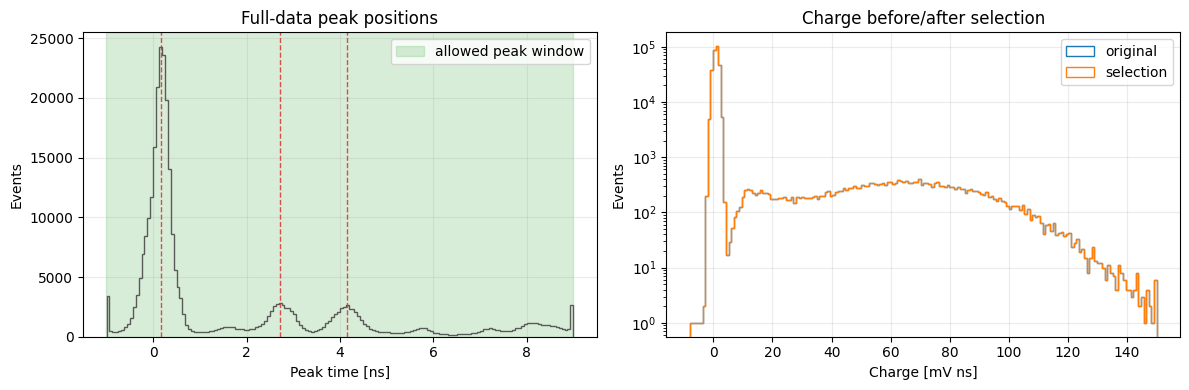

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Peak-time histogram
counts, edges, _ = axes[0].hist(
    selection["peak_time_ns"],
    bins=160,
    histtype="step",
    color="0.35",
)

centers = 0.5 * (edges[:-1] + edges[1:])

# Approximate peak finding, no fit
from scipy.signal import find_peaks

peaks, props = find_peaks(
    counts,
    prominence=0.05 * np.max(counts),
    distance=5,
)

peak_times = centers[peaks]
peak_heights = counts[peaks]

# Sort peaks by height, keep the most relevant few, then order by time
n_show = 12 #min(4, len(peak_times))
idx = np.argsort(peak_heights)[-n_show:]
peak_times_main = np.sort(peak_times[idx])

# Draw peak markers
for t in peak_times_main:
    axes[0].axvline(t, color="tab:red", ls="--", lw=1, alpha=0.8)

# Estimate separations between neighboring peaks
if len(peak_times_main) >= 2:
    dt_peaks = np.diff(peak_times_main)

    txt = "Peak spacing:\n" + "\n".join(
        f"{dt:.2f} ns" for dt in dt_peaks
    )

    print("Approximate peak positions [ns]:", peak_times_main)
    print("Approximate spacings [ns]:", dt_peaks)
else:
    print("Not enough peaks found to estimate spacing.")

axes[0].axvspan(
    *allowed_peak_window_ns,
    color="tab:green",
    alpha=0.18,
    label="allowed peak window",
)
axes[0].set_xlabel("Peak time [ns]")
axes[0].set_ylabel("Events")
axes[0].set_title("Full-data peak positions")
axes[0].legend()

axes[1].hist(charge_all_mV_ns, bins=180, range=(-8, 150), histtype="step", label="original")
axes[1].hist(charge_selected_mV_ns, bins=180, range=(-8, 150), histtype="step", label="selection")
axes[1].set_xlabel("Charge [mV ns]")
axes[1].set_ylabel("Events")
axes[1].set_title("Charge before/after selection")
axes[1].set_yscale("log")
axes[1].legend()
fig.tight_layout()